# Figure 5 — Source detection on Euclid VIS (MER Q1 as the independent reference)

Source lists for the same ECDFS field, in three categories:

| category | methods | what it is |
|---|---|---|
| classical pixel detector (we run) | **SEP** | single-band VIS, no learning (chosen over a plain peak-finder: SEP is Pareto-better vs MER) |
| foundation detectors (we run) | CenterNet, StemCenterNet | frozen multi-band encoder + heads |
| external real catalog | **MER Q1** | Euclid pipeline catalog — the independent reference |

**(a)** All overlaid on a VIS cutout. **(b)** Pairwise agreement matrix: entry $(i,j)$ =
fraction of method $i$'s sources confirmed by a method-$j$ source within $0.5''$, pooled
over the 10 seeded ECDFS tiles. MER is the designated reference (boxed): its **column** ≈
purity-vs-MER, its **row** ≈ completeness-vs-MER.

`REGEN` (auto if cache missing) loads the frozen foundation + both heads, runs all
detectors (incl. the peak-finder, kept for the SEP-vs-classical justification) over the
seeded tiles, matches MER by per-tile VIS WCS, and caches every tile's image + lists to
`_fig5_detection_cache.pkl` so the overlay cutout can be re-chosen with no GPU.
Saves `paper/figures/fig5_detection.png`.

In [1]:
import sys, pickle
from pathlib import Path
import numpy as np

def find_repo_root(start=None):
    start = (start or Path.cwd()).resolve()
    for cand in [start, *start.parents]:
        if (cand / 'models').exists() and (cand / 'data').exists():
            return cand
    raise FileNotFoundError('repo root not found')

REPO = find_repo_root()
NB = Path.cwd()
CACHE = NB / '_fig5_detection_cache.pkl'
OUT = REPO / 'paper' / 'figures' / 'fig5_detection.png'
MER_FITS = REPO / 'data' / 'edf_s_ood' / 'catalogs_compact' / 'mer_FINAL_q1_ECDFS_footprint.fits'

TILES = ['tile_x01280_y01792_tract5063_patch_24','tile_x02304_y02048_tract5063_patch_14',
         'tile_x01024_y00512_tract5063_patch_24','tile_x01792_y02048_tract5063_patch_14',
         'tile_x01280_y00768_tract5063_patch_5','tile_x00000_y00512_tract5063_patch_5',
         'tile_x00768_y01280_tract5063_patch_25','tile_x00256_y00768_tract5063_patch_25',
         'tile_x01536_y00000_tract5063_patch_4','tile_x00000_y01536_tract5063_patch_25']
# All 5 are computed; ALL_METHODS index order is fixed. The FIGURE shows PLOT_IDX only.
ALL_METHODS = ['Classical VIS', 'SEP', 'CenterNet', 'StemCenterNet', 'MER']
PLOT_IDX = [1, 2, 3, 4]                          # SEP, CenterNet, StemCenterNet, MER
OVERLAY_TILE = 'tile_x01280_y00768_tract5063_patch_5'
ZOOM = (380, 820)                                # VIS-px crop window for the overlay
CENTERNET_CONF, STEM_CONF, CLASSICAL_NSIG, SEP_THRESH = 0.30, 0.55, 3.0, 2.0
MATCH_ARCSEC, PXSCALE_VIS = 0.5, 0.1
MATCH_PX = MATCH_ARCSEC / PXSCALE_VIS

REGEN = not CACHE.exists()
print(f'REPO {REPO}\nCACHE exists={CACHE.exists()}  REGEN={REGEN}')

REPO /home/shemmati/Work/Projects/JAISP
CACHE exists=False  REGEN=True


In [2]:
if REGEN:
    import torch, sep
    from astropy.table import Table
    from astropy.wcs import WCS
    from scipy.spatial import cKDTree
    MODELS = REPO / 'models'
    for p in [MODELS, MODELS/'detection', MODELS/'astrometry2']:
        if str(p) not in sys.path: sys.path.insert(0, str(p))
    from load_foundation import load_foundation
    from detection.centernet_detector import CenterNetDetector
    from detection.detector import JAISPEncoderWrapper
    from detection.stem_centernet_detector import StemCenterNetDetector
    from detection.dataset import _pseudo_labels_vis
    from astrometry2.source_matching import safe_header_from_card_string

    DEV = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    FCK = MODELS/'checkpoints'/'jaisp_v10_warmstart'/'checkpoint_best.pt'
    CCK = REPO/'checkpoints'/'centernet_v10_uncertain_synth_r2'/'centernet_best.pt'
    SCK = REPO/'checkpoints'/'stem_centernet_v10_uncertain_synth_r2'/'stem_centernet_best.pt'
    RDIR, EDIR = REPO/'data'/'rubin_tiles_all', REPO/'data'/'euclid_tiles_all'

    def safe_rms(v):
        v = np.asarray(v, np.float32); g = np.isfinite(v)&(v>0)&(v<1e20)
        fb = float(np.sqrt(np.median(v[g]))) if g.any() else 1.0
        o = np.full(v.shape, fb, np.float32); o[g] = np.sqrt(v[g]); return o
    def t1(a): return torch.from_numpy(np.asarray(a, np.float32)[None,None]).to(DEV)

    def load_tile(stem):
        r = np.load(RDIR/f'{stem}.npz', allow_pickle=True)
        e = np.load(EDIR/f'{stem}_euclid.npz', allow_pickle=True)
        rimg = np.nan_to_num(np.asarray(r['img'], np.float32))
        rrms = np.stack([safe_rms(v) for v in np.asarray(r['var'], np.float32)], 0)
        vis = np.nan_to_num(np.asarray(e['img_VIS'], np.float32))
        var_vis = np.asarray(e['var_VIS'], np.float32)
        rb = ['u','g','r','i','z','y']
        images = {f'rubin_{b}': t1(rimg[k]) for k,b in enumerate(rb)}
        rms = {f'rubin_{b}': t1(rrms[k]) for k,b in enumerate(rb)}
        for b in ['VIS','Y','J','H']:
            images[f'euclid_{b}'] = t1(np.nan_to_num(np.asarray(e[f'img_{b}'], np.float32)))
            rms[f'euclid_{b}'] = t1(safe_rms(e[f'var_{b}']))
        wcs = WCS(safe_header_from_card_string(e['wcs_VIS'].item()))
        return vis, var_vis, tuple(vis.shape), images, rms, wcs

    def classical_xy(vis, hw):
        c,_,_,_ = _pseudo_labels_vis(vis, nsig=CLASSICAL_NSIG, max_sources=1000)
        h,w = hw
        if len(c)==0: return np.zeros((0,2),np.float32)
        return np.stack([c[:,0]*(w-1), c[:,1]*(h-1)],1).astype(np.float32)

    def sep_xy(vis, var_vis):
        data = np.ascontiguousarray(vis, np.float32)
        bkg = sep.Background(data); sub = data - bkg.back(); err = safe_rms(var_vis)
        try:
            obj = sep.extract(sub, thresh=SEP_THRESH, err=err, minarea=5, deblend_cont=0.005)
        except Exception:
            obj = sep.extract(sub, thresh=SEP_THRESH, err=float(bkg.globalrms), minarea=5)
        return np.stack([np.asarray(obj['x'],np.float32), np.asarray(obj['y'],np.float32)],1)

    def run_det(det, images, rms, hw, conf):
        with torch.no_grad():
            p = det.predict(images, rms, conf_threshold=conf, tile_hw=hw, artifact_mask=None)
        return p['positions_px'].cpu().numpy().astype(np.float32)

    def mer_xy(wcs, hw):
        h,w = hw
        px,py = wcs.all_world2pix(MER_RA, MER_DEC, 0)
        px = np.asarray(px); py = np.asarray(py)
        m = np.isfinite(px)&np.isfinite(py)&(px>=0)&(px<w)&(py>=0)&(py<h)
        return np.stack([px[m], py[m]],1).astype(np.float32)

    cat = Table.read(MER_FITS)
    clean = (np.asarray(cat['vis_det'])==1) & (np.asarray(cat['spurious_flag'])!=1)
    MER_RA = np.asarray(cat['ra'], float)[clean]; MER_DEC = np.asarray(cat['dec'], float)[clean]
    print(f'clean MER sources (field): {clean.sum()}')

    print('loading foundation + heads ...')
    foundation = load_foundation(str(FCK), device=DEV, freeze=True)
    enc = JAISPEncoderWrapper(foundation, freeze=True).to(DEV)
    cnet = CenterNetDetector.load(str(CCK), encoder=enc, device=DEV).eval()
    snet = StemCenterNetDetector.load(str(SCK), foundation, device=DEV).eval()

    def frac_matched(A, B, rad):
        if len(A)==0: return (0,0)
        if len(B)==0: return (0,len(A))
        d,_ = cKDTree(B).query(A, k=1)
        return (int((d<=rad).sum()), len(A))

    n = len(ALL_METHODS)
    tiles_data, per_tile = {}, {}
    NUM = np.zeros((n,n)); DEN = np.zeros((n,n))
    for st in TILES:
        vis, var_vis, hw, images, rms, wcs = load_tile(st)
        lists = [classical_xy(vis, hw), sep_xy(vis, var_vis),
                 run_det(cnet, images, rms, hw, CENTERNET_CONF),
                 run_det(snet, images, rms, hw, STEM_CONF), mer_xy(wcs, hw)]
        per_tile[st] = [int(len(x)) for x in lists]
        for i in range(n):
            for j in range(n):
                if i==j: NUM[i,j]+=len(lists[i]); DEN[i,j]+=len(lists[i]); continue
                a,d = frac_matched(lists[i], lists[j], MATCH_PX); NUM[i,j]+=a; DEN[i,j]+=d
        tiles_data[st] = dict(vis=vis.astype(np.float16), hw=hw,
                              lists=[x.astype(np.float32) for x in lists])
        print(f'  {st}: ' + ' '.join(f'{m}={len(x)}' for m,x in zip(["VIS","SEP","CN","ST","MER"], lists)))

    M = np.divide(NUM, np.maximum(DEN,1))
    pickle.dump(dict(M=M, NUM=NUM, DEN=DEN, per_tile=per_tile, tiles_data=tiles_data,
                     methods=ALL_METHODS, match_arcsec=MATCH_ARCSEC,
                     centernet_conf=CENTERNET_CONF, stem_conf=STEM_CONF,
                     sep_thresh=SEP_THRESH, classical_nsig=CLASSICAL_NSIG,
                     n_tiles=len(TILES)), open(CACHE,'wb'))
    print('cached ->', CACHE)
    del foundation, enc, cnet, snet
    if DEV.type=='cuda': torch.cuda.empty_cache()
else:
    print('REGEN skipped (cache present).')

clean MER sources (field): 49125
loading foundation + heads ...
JAISPFoundationV10: 9.2M trainable parameters
  stem_ch=64, hidden_ch=256, fused_scale=0.40"/px
  stream_depths={'rubin': 1, 'euclid': 2}
  rubin_concat=True  (symmetric concat fusion)
  loss_type=charbonnier  charbonnier_eps=0.001  core_l2_weight=0.2  core_info_thr=0.5
  rubin decoder channels: [128]
  euclid decoder channels: [256, 128]


Loaded v10 foundation (fused_scale=0.4, rubin_concat=True, loss=charbonnier, core_l2=0.2) from /home/shemmati/Work/Projects/JAISP/models/checkpoints/jaisp_v10_warmstart/checkpoint_best.pt


  tile_x01280_y01792_tract5063_patch_24: VIS=425 SEP=431 CN=468 ST=437 MER=234


  tile_x02304_y02048_tract5063_patch_14: VIS=471 SEP=430 CN=436 ST=485 MER=243


  tile_x01024_y00512_tract5063_patch_24: VIS=393 SEP=397 CN=493 ST=443 MER=214


...

  tile_x00000_y00512_tract5063_patch_5: VIS=384 SEP=364 CN=352 ST=416 MER=212


  tile_x00768_y01280_tract5063_patch_25: VIS=519 SEP=462 CN=584 ST=547 MER=283


  tile_x00256_y00768_tract5063_patch_25: VIS=425 SEP=316 CN=431 ST=446 MER=251


  tile_x01536_y00000_tract5063_patch_4: VIS=445 SEP=403 CN=346 ST=451 MER=234


  tile_x00000_y01536_tract5063_patch_25: VIS=385 SEP=410 CN=425 ST=427 MER=211
cached -> /home/shemmati/Work/Projects/JAISP/paper_figures/_fig5_detection_cache.pkl


Classical-detector check vs MER (10 tiles):
  VIS peak-finder  completeness=  86%  purity=  47%  F1=0.61
  SEP              completeness=  94%  purity=  56%  F1=0.70


saved -> /home/shemmati/Work/Projects/JAISP/paper/figures/fig5_detection.png


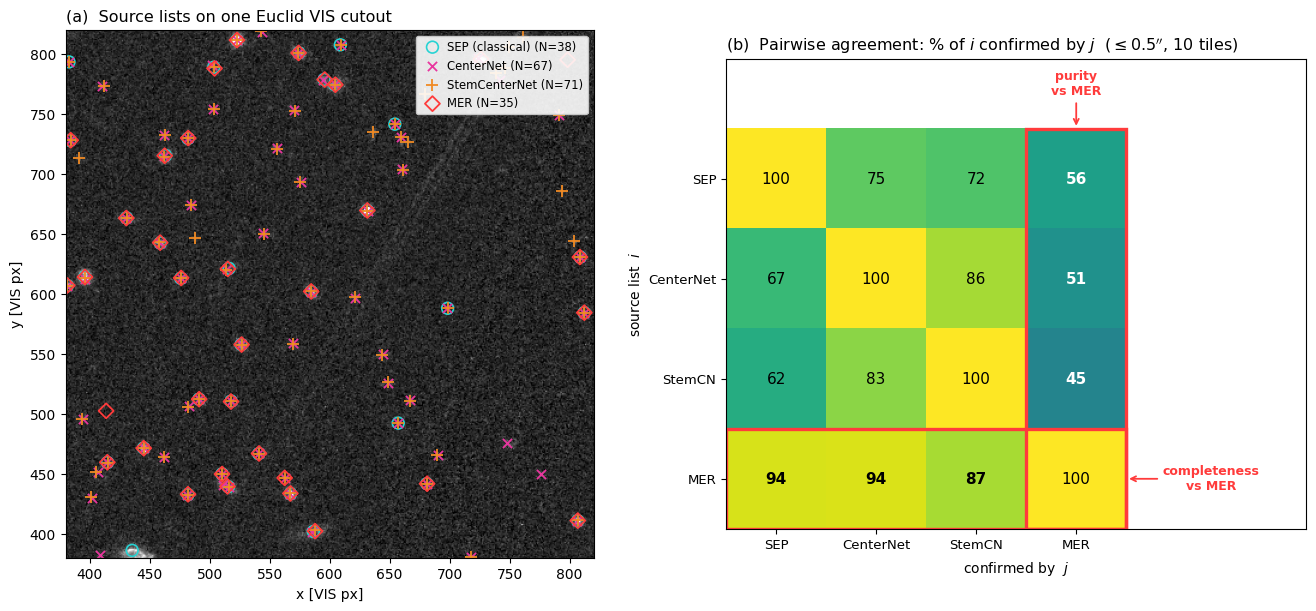

In [3]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle

c = pickle.load(open(CACHE,'rb'))
M5 = c['M']; ALLM = c['methods']
td = c['tiles_data'][OVERLAY_TILE]
z0, z1 = ZOOM
idx = PLOT_IDX
methods = [ALLM[i] for i in idx]
M = M5[np.ix_(idx, idx)]

# SEP-vs-peakfinder justification (vs MER = last index 4)
mer = 4
print('Classical-detector check vs MER (10 tiles):')
for k, lab in [(0,'VIS peak-finder'), (1,'SEP')]:
    comp, pur = M5[mer,k], M5[k,mer]
    f1 = 2*comp*pur/max(comp+pur,1e-9)
    print(f'  {lab:16s} completeness={comp*100:4.0f}%  purity={pur*100:4.0f}%  F1={f1:.2f}')

def stretch(img, lo=1.0, hi=99.5):
    img = np.asarray(img, np.float32); f = np.isfinite(img)
    vmin, vmax = np.percentile(img[f], [lo,hi]); vmax = max(vmax, vmin+1e-6)
    return np.clip((np.nan_to_num(img, nan=vmin)-vmin)/(vmax-vmin), 0, 1)

# styles keyed by ALL_METHODS index
STY = {0: dict(marker='o', s=70, facecolors='none', edgecolors='#27d3d3', lw=1.1),
       1: dict(marker='o', s=72, facecolors='none', edgecolors='#27d3d3', lw=1.2),  # SEP=classical -> cyan
       2: dict(marker='x', s=44, c='#e8369e', lw=1.3),
       3: dict(marker='+', s=64, c='#f08a24', lw=1.3),
       4: dict(marker='D', s=58, facecolors='none', edgecolors='#ff3b3b', lw=1.3)}
LABELS = {1: 'SEP (classical)', 2: 'CenterNet', 3: 'StemCenterNet', 4: 'MER'}

fig = plt.figure(figsize=(13.6, 6.6))
gs = GridSpec(1, 2, width_ratios=[1.04, 1.0], wspace=0.16,
              left=0.045, right=0.985, top=0.90, bottom=0.10)

# ---- (a) overlay ----
axL = fig.add_subplot(gs[0,0])
axL.imshow(stretch(td['vis'].astype(np.float32)), origin='lower', cmap='gray', vmin=0, vmax=1)
for i in idx:
    xy = td['lists'][i]
    m = (xy[:,0]>=z0)&(xy[:,0]<z1)&(xy[:,1]>=z0)&(xy[:,1]<z1)
    axL.scatter(xy[m,0], xy[m,1], label=f'{LABELS[i]} (N={int(m.sum())})', **STY[i])
axL.set_xlim(z0, z1); axL.set_ylim(z0, z1)
axL.set_xlabel('x [VIS px]'); axL.set_ylabel('y [VIS px]')
axL.set_title('(a)  Source lists on one Euclid VIS cutout', loc='left', fontsize=11.5)
leg = axL.legend(loc='upper right', fontsize=8.4, framealpha=0.9, facecolor='white',
                 handletextpad=0.25, borderpad=0.4)
for t in leg.get_texts(): t.set_color('black')

# ---- (b) agreement matrix ----
axR = fig.add_subplot(gs[0,1])
nm = len(idx); mer_pos = idx.index(4)
im = axR.imshow(M, cmap='viridis', vmin=0, vmax=1)
short = {1:'SEP', 2:'CenterNet', 3:'StemCN', 4:'MER'}
labs = [short[i] for i in idx]
axR.set_xticks(range(nm)); axR.set_xticklabels(labs, fontsize=9.5)
axR.set_yticks(range(nm)); axR.set_yticklabels(labs, fontsize=9.5)
for a in range(nm):
    for b in range(nm):
        v = M[a,b]
        axR.text(b, a, f'{v*100:.0f}', ha='center', va='center', fontsize=11,
                 color='white' if v<0.6 else 'black',
                 fontweight='bold' if (a==mer_pos or b==mer_pos) and a!=b else 'normal')
axR.add_patch(Rectangle((mer_pos-0.5,-0.5), 1, nm, fill=False, edgecolor='#ff3b3b', lw=2.4))
axR.add_patch(Rectangle((-0.5,mer_pos-0.5), nm, 1, fill=False, edgecolor='#ff3b3b', lw=2.4))
axR.set_xlabel('confirmed by  $j$', labelpad=6); axR.set_ylabel('source list  $i$')
axR.set_title('(b)  Pairwise agreement: % of $i$ confirmed by $j$  ' +
              f"($\\leq{c['match_arcsec']}''$, {c['n_tiles']} tiles)", loc='left', fontsize=11.5)
axR.annotate('purity\nvs MER', xy=(mer_pos, -0.5), xytext=(mer_pos, -0.95), ha='center', va='center',
             fontsize=9, color='#ff3b3b', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#ff3b3b', lw=1.3))
axR.annotate('completeness\nvs MER', xy=(mer_pos+0.5, mer_pos), xytext=(mer_pos+1.35, mer_pos),
             ha='center', va='center', fontsize=9, color='#ff3b3b', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#ff3b3b', lw=1.3))
axR.set_xlim(-0.5, nm+1.3); axR.set_ylim(nm-0.5, -1.2); axR.set_aspect('equal')

fig.savefig(OUT, dpi=300, bbox_inches='tight', facecolor='white')
print('saved ->', OUT)
plt.show()